<a href="https://colab.research.google.com/github/vnissi2010-cmyk/City-population-Migration-Model/blob/main/City_population_Migration_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Initial population of 3 cities
P0 = np.array([100000, 80000, 60000], dtype=float)

# Migration matrix
# Each column shows where people from that city go.
M = np.array([
    [0.80, 0.10, 0.10],
    [0.10, 0.80, 0.10],
    [0.10, 0.10, 0.80]
])

years = 10

print("Initial Population:")
print("City A:", P0[0])
print("City B:", P0[1])
print("City C:", P0[2])

print("\nMigration Matrix:")
print(M)

Initial Population:
City A: 100000.0
City B: 80000.0
City C: 60000.0

Migration Matrix:
[[0.8 0.1 0.1]
 [0.1 0.8 0.1]
 [0.1 0.1 0.8]]


In [ ]:
# Calculate population for each year
populations = [P0]

for year in range(1, years + 1):
    next_population = M @ populations[-1]
    populations.append(next_population)

populations = np.array(populations)

print("Population after", years, "years:")
print(populations[-1])

Population after 10 years:
[80564.950498 80000.       79435.049502]


In [ ]:
# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(M)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# Check diagonalization: M = P D P^-1
P = eigenvectors
D = np.diag(eigenvalues)

M_reconstructed = P @ D @ np.linalg.inv(P)

print("\nReconstructed Matrix:")
print(np.round(M_reconstructed, 6))

Eigenvalues:
[0.7 1.  0.7]

Eigenvectors:
[[-0.81649658  0.57735027  0.10788078]
 [ 0.40824829  0.57735027 -0.75484787]
 [ 0.40824829  0.57735027  0.6469671 ]]

Reconstructed Matrix:
[[0.8 0.1 0.1]
 [0.1 0.8 0.1]
 [0.1 0.1 0.8]]


In [ ]:
# M = P D P^-1

P_matrix = eigenvectors
D_matrix = np.diag(eigenvalues)

M_from_diagonalization = (
    P_matrix @ D_matrix @ np.linalg.inv(P_matrix)
)

print("Original Matrix M:")
print(M)

print("\nP D P^-1:")
print(np.round(M_from_diagonalization.real, 4))

print("\nDiagonalization is verified.")

In [ ]:
n = 5

M_power = np.linalg.matrix_power(M, n)

print("M^5 =")
print(np.round(M_power, 4))

final_population = M_power @ P0

print("\nPopulation after 5 years:")
print(np.round(final_population, 2))

M^5 =
[[0.4454 0.2773 0.2773]
 [0.2773 0.4454 0.2773]
 [0.2773 0.2773 0.4454]]

Population after 5 years:
[83361.4 80000.  76638.6]


In [ ]:
P_matrix = eigenvectors
D_matrix = np.diag(eigenvalues)

M_check = P_matrix @ D_matrix @ np.linalg.inv(P_matrix)

print("P D P^-1 =")
print(np.round(M_check.real, 4))

P D P^-1 =
[[0.8 0.1 0.1]
 [0.1 0.8 0.1]
 [0.1 0.1 0.8]]


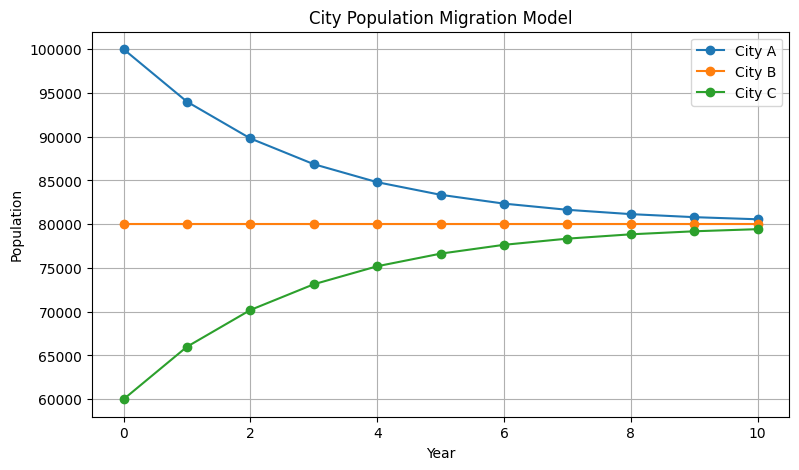

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(range(years + 1), populations[:, 0], marker="o", label="City A")
plt.plot(range(years + 1), populations[:, 1], marker="o", label="City B")
plt.plot(range(years + 1), populations[:, 2], marker="o", label="City C")

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("City Population Migration Model")
plt.legend()
plt.grid(True)
plt.show()